# $(SASA) Models - Kmodels$

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pickle
import numpy as np
import pandas as pd

from pmbrl.model2 import Base_Line_Simple_Model
# from pmbrl.model2 import Model, Regularized_Reference_Loss
from pmbrl.data import Experiment_Data, get_data_expanded, get_data_compacted

In [2]:
data = Experiment_Data()

data.load(path='../training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
880,4,36,"(0.0299166252862626, 0.5232478091465481)","(-0.01, 0.764, 0.008, -1.034)",0,1.0,"(0.006, 0.57, -0.013, -0.766)",1.0,1.0,"(0.017, 0.764, -0.028, -1.035)"
2080,37,81,"(0.1825292152212203, 0.91730535067745)","(0.14, 0.521, 0.038, -0.079)",0,1.0,"(0.15, 0.331, 0.036, 0.097)",1.0,1.0,"(0.157, 0.52, 0.038, -0.066)"
1136,34,46,"(0.5759890361457483, 0.539204361971833)","(-0.132, -0.403, 0.037, -0.047)",0,1.0,"(-0.14, -0.605, 0.036, 0.386)",1.0,1.0,"(-0.153, -0.405, 0.044, -0.014)"
1200,2,49,"(0.3032155985016214, 0.5787433112675132)","(-0.009, 0.4, -0.016, -0.588)",1,1.0,"(-0.001, 0.596, -0.028, -0.891)",1.0,1.0,"(0.01, 0.792, -0.046, -1.196)"
1189,14,48,"(0.0305155657975269, 0.7546497874201262)","(0.041, 0.77, -0.039, -0.708)",1,1.0,"(0.056, 0.96, -0.053, -0.9)",0.0,1.0,"(0.075, 0.771, -0.072, -0.727)"
...,...,...,...,...,...,...,...,...,...,...
1912,16,76,"(0.0250474928798763, 0.8242933987226606)","(-0.007, -0.711, 0.077, 0.741)",0,1.0,"(-0.021, -0.901, 0.092, 0.923)",0.0,1.0,"(-0.039, -1.091, 0.11, 1.107)"
1598,20,65,"(0.1785778102029531, 1.438381745613701)","(0.038, 0.379, -0.08, -0.32)",0,1.0,"(0.046, 0.192, -0.086, -0.222)",0.0,1.0,"(0.049, 0.006, -0.091, -0.124)"
934,19,38,"(0.4545373771214862, 0.5810082803318615)","(0.03, 0.158, 0.001, -0.02)",0,1.0,"(0.033, -0.039, 0.001, 0.321)",1.0,1.0,"(0.033, 0.158, 0.007, -0.019)"
387,33,13,"(0.2403247570594251, 0.7298838219922094)","(0.029, -1.306, 0.065, 1.489)",1,1.0,"(0.002, -1.115, 0.095, 1.282)",1.0,1.0,"(-0.02, -0.924, 0.12, 1.082)"


In [3]:
expansions = {
    's': ['s0', 's1', 's2', 's3'],
    's_': ['s_0', 's_1', 's_2', 's_3'],
    'p': ['p0', 'p1'],
}

df = get_data_expanded(data.build_training_dataset(), expansions)
# df = df.loc[df['episode']<15].copy()
df

,step,episode,p,s,a,r,s_,a_,r_,s__,s0,s1,s2,s3,s_0,s_1,s_2,s_3,p0,p1
840,26,31,"(0.202531051367323, 0.357238297754249)","(-0.015, -0.477, 0.174, 1.553)",1,1.0,"(-0.024, -0.279, 0.206, 1.2)",0.0,1.0,"(-0.03, -0.484, 0.23, 1.727)",-0.015,-0.477,0.174,1.553,-0.024,-0.279,0.206,1.200,0.202531,0.357238
401,9,14,"(0.3661060257466248, 0.7420528554871)","(-0.062, -0.599, 0.152, 0.927)",1,1.0,"(-0.074, -0.408, 0.17, 0.726)",0.0,1.0,"(-0.083, -0.603, 0.185, 1.01)",-0.062,-0.599,0.152,0.927,-0.074,-0.408,0.170,0.726,0.366106,0.742053
201,85,6,"(0.2451557536988955, 1.3793967951445396)","(-0.392, -0.184, -0.063, -0.308)",1,1.0,"(-0.396, 0.003, -0.069, -0.434)",1.0,1.0,"(-0.396, 0.191, -0.078, -0.561)",-0.392,-0.184,-0.063,-0.308,-0.396,0.003,-0.069,-0.434,0.245156,1.379397
570,7,21,"(0.3094422912440924, 0.4357216409942268)","(0.105, 0.613, -0.134, -1.295)",1,1.0,"(0.118, 0.814, -0.16, -1.742)",1.0,1.0,"(0.134, 1.016, -0.195, -2.198)",0.105,0.613,-0.134,-1.295,0.118,0.814,-0.160,-1.742,0.309442,0.435722
163,47,6,"(0.2451557536988955, 1.3793967951445396)","(-0.028, -0.196, -0.059, -0.043)",1,1.0,"(-0.031, -0.009, -0.06, -0.169)",0.0,1.0,"(-0.032, -0.195, -0.063, -0.058)",-0.028,-0.196,-0.059,-0.043,-0.031,-0.009,-0.060,-0.169,0.245156,1.379397
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1558,12,64,"(0.3183694304142259, 0.9452629977131142)","(0.076, 0.01, -0.094, -0.197)",0,1.0,"(0.076, -0.179, -0.098, -0.032)",0.0,1.0,"(0.073, -0.368, -0.098, 0.131)",0.076,0.010,-0.094,-0.197,0.076,-0.179,-0.098,-0.032,0.318369,0.945263
191,75,6,"(0.2451557536988955, 1.3793967951445396)","(-0.307, -0.935, -0.038, 0.218)",1,1.0,"(-0.325, -0.748, -0.034, 0.095)",1.0,1.0,"(-0.34, -0.56, -0.032, -0.028)",-0.307,-0.935,-0.038,0.218,-0.325,-0.748,-0.034,0.095,0.245156,1.379397
1913,17,76,"(0.0250474928798763, 0.8242933987226606)","(-0.021, -0.901, 0.092, 0.923)",0,1.0,"(-0.039, -1.091, 0.11, 1.107)",1.0,1.0,"(-0.061, -0.903, 0.132, 0.96)",-0.021,-0.901,0.092,0.923,-0.039,-1.091,0.110,1.107,0.025047,0.824293
203,87,6,"(0.2451557536988955, 1.3793967951445396)","(-0.396, 0.191, -0.078, -0.561)",0,1.0,"(-0.392, 0.004, -0.089, -0.453)",0.0,1.0,"(-0.392, -0.182, -0.098, -0.346)",-0.396,0.191,-0.078,-0.561,-0.392,0.004,-0.089,-0.453,0.245156,1.379397


# Initialization by Random Partitioning

In [4]:
k = 5
models = [Base_Line_Simple_Model() for _ in range(k)]
# params = [1/k for _ in range(k)]

In [5]:
groups = np.random.randint(low=0, high=k, size=df.episode.unique().shape[0])
df['group'] = np.nan

for i, g in enumerate(groups):
    df.loc[df['episode']==i,'group'] = g
df

,step,episode,p,s,a,r,s_,a_,r_,s__,...,s1,s2,s3,s_0,s_1,s_2,s_3,p0,p1,group
840,26,31,"(0.202531051367323, 0.357238297754249)","(-0.015, -0.477, 0.174, 1.553)",1,1.0,"(-0.024, -0.279, 0.206, 1.2)",0.0,1.0,"(-0.03, -0.484, 0.23, 1.727)",...,-0.477,0.174,1.553,-0.024,-0.279,0.206,1.200,0.202531,0.357238,0.0
401,9,14,"(0.3661060257466248, 0.7420528554871)","(-0.062, -0.599, 0.152, 0.927)",1,1.0,"(-0.074, -0.408, 0.17, 0.726)",0.0,1.0,"(-0.083, -0.603, 0.185, 1.01)",...,-0.599,0.152,0.927,-0.074,-0.408,0.170,0.726,0.366106,0.742053,4.0
201,85,6,"(0.2451557536988955, 1.3793967951445396)","(-0.392, -0.184, -0.063, -0.308)",1,1.0,"(-0.396, 0.003, -0.069, -0.434)",1.0,1.0,"(-0.396, 0.191, -0.078, -0.561)",...,-0.184,-0.063,-0.308,-0.396,0.003,-0.069,-0.434,0.245156,1.379397,1.0
570,7,21,"(0.3094422912440924, 0.4357216409942268)","(0.105, 0.613, -0.134, -1.295)",1,1.0,"(0.118, 0.814, -0.16, -1.742)",1.0,1.0,"(0.134, 1.016, -0.195, -2.198)",...,0.613,-0.134,-1.295,0.118,0.814,-0.160,-1.742,0.309442,0.435722,2.0
163,47,6,"(0.2451557536988955, 1.3793967951445396)","(-0.028, -0.196, -0.059, -0.043)",1,1.0,"(-0.031, -0.009, -0.06, -0.169)",0.0,1.0,"(-0.032, -0.195, -0.063, -0.058)",...,-0.196,-0.059,-0.043,-0.031,-0.009,-0.060,-0.169,0.245156,1.379397,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1558,12,64,"(0.3183694304142259, 0.9452629977131142)","(0.076, 0.01, -0.094, -0.197)",0,1.0,"(0.076, -0.179, -0.098, -0.032)",0.0,1.0,"(0.073, -0.368, -0.098, 0.131)",...,0.010,-0.094,-0.197,0.076,-0.179,-0.098,-0.032,0.318369,0.945263,1.0
191,75,6,"(0.2451557536988955, 1.3793967951445396)","(-0.307, -0.935, -0.038, 0.218)",1,1.0,"(-0.325, -0.748, -0.034, 0.095)",1.0,1.0,"(-0.34, -0.56, -0.032, -0.028)",...,-0.935,-0.038,0.218,-0.325,-0.748,-0.034,0.095,0.245156,1.379397,1.0
1913,17,76,"(0.0250474928798763, 0.8242933987226606)","(-0.021, -0.901, 0.092, 0.923)",0,1.0,"(-0.039, -1.091, 0.11, 1.107)",1.0,1.0,"(-0.061, -0.903, 0.132, 0.96)",...,-0.901,0.092,0.923,-0.039,-1.091,0.110,1.107,0.025047,0.824293,1.0
203,87,6,"(0.2451557536988955, 1.3793967951445396)","(-0.396, 0.191, -0.078, -0.561)",0,1.0,"(-0.392, 0.004, -0.089, -0.453)",0.0,1.0,"(-0.392, -0.182, -0.098, -0.346)",...,0.191,-0.078,-0.561,-0.392,0.004,-0.089,-0.453,0.245156,1.379397,1.0


## Initial Training 

In [6]:
def train_models(models, train_dataset):
    train_data = [None for _ in models]

    for g, model in enumerate(models):
        # print('train model: ', g)
        group_data = train_dataset.loc[train_dataset['group']==g]
        if group_data.shape[0] > 0:
            x, y = model.get_features_targets(group_data)
            trainer = model.train(x, y, num_epochs=1000)
            train_data[g] = data.get_training_data(trainer, inference_schema=model.inference_schema)
    
    return train_data


In [7]:
train_data = train_models(models, df[[
    's', 's_', 's__', 'a', 'a_', 'r', 'p', 'group'
]])

train_data[0].head()

,epoch,mse_s,transition,reward
0,0,"[0.04002439230680466, 0.6250930428504944, 0.07...",1.534493,1.156041
1,1,"[0.03916751593351364, 0.6209737062454224, 0.07...",1.522689,1.150081
2,2,"[0.03832344338297844, 0.6168997287750244, 0.07...",1.511041,1.144200
3,3,"[0.03749324753880501, 0.6128634214401245, 0.07...",1.499549,1.138403
4,4,"[0.036677442491054535, 0.6088617444038391, 0.0...",1.488212,1.132693


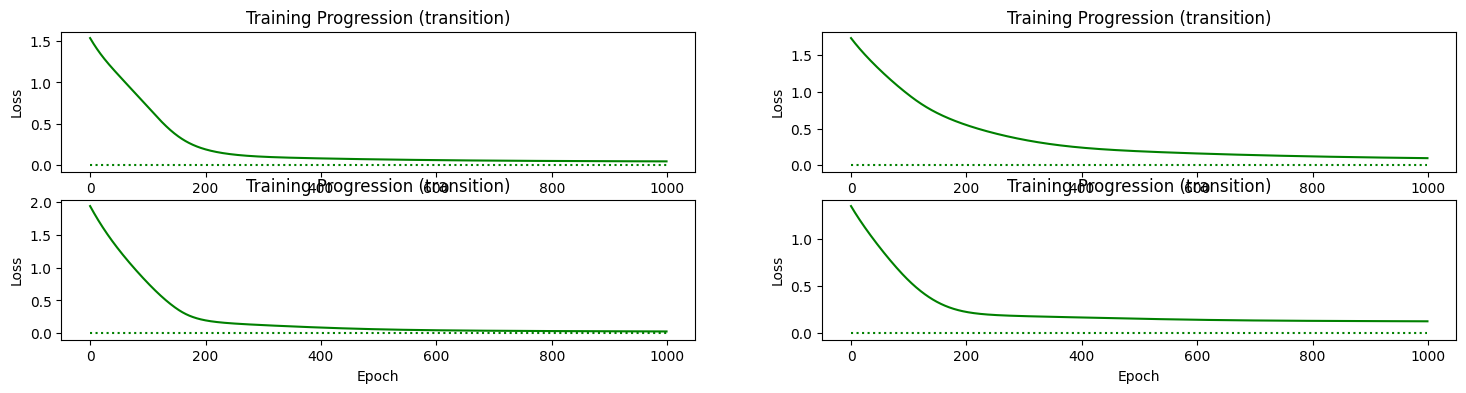

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(18, 4))

data.plot_training_loss(axs[0][0], train_data[0].transition)
data.plot_training_loss(axs[0][1], train_data[1].transition)
data.plot_training_loss(axs[1][0], train_data[2].transition)
data.plot_training_loss(axs[1][1], train_data[3].transition)

plt.show()

# Predict 

In [9]:
M = [10,20,30,40,50]
D = [1,2,3]

# [[m*d for d in D]for m in M]
# np.sum([[m*d for d in D]for m in M], axis=0)
np.sum([[m*d for m in M] for d in D], axis=1)

array([150, 300, 450])

In [10]:
def get_model_metrics(prediction_dataset, results, i):
    prediction_dataset[f'rse_model_{i}'] = results['rse']
    prediction_dataset[f'rse_normalized_model_{i}'] = results['rse_normalized']

    prediction_dataset[f'rse_s0_model_{i}'] = results['rse_s0']
    prediction_dataset[f'rse_s1_model_{i}'] = results['rse_s1']
    prediction_dataset[f'rse_s2_model_{i}'] = results['rse_s2']
    prediction_dataset[f'rse_s3_model_{i}'] = results['rse_s3']

    prediction_dataset[f'rse_s0_normalized_model_{i}'] = results['rse_s0_normalized']
    prediction_dataset[f'rse_s1_normalized_model_{i}'] = results['rse_s1_normalized']
    prediction_dataset[f'rse_s2_normalized_model_{i}'] = results['rse_s2_normalized']
    prediction_dataset[f'rse_s3_normalized_model_{i}'] = results['rse_s3_normalized']


def evaluate(models, df):
    def predict(model):
        prediction_dataset = df.copy()
        prediction_dataset[model.grouped_targets_lables] = prediction_dataset.apply(lambda row: data._predict_from_row(row, model), axis=1, result_type='expand')
        return prediction_dataset
    
    def optim_params(prediction_dataset):
        weights = df.copy()
        for m, estimated_data in enumerate(prediction_dataset):
            expansions = {f'estimated_s': [f'estimated_s0', f'estimated_s1', f'estimated_s2', f'estimated_s3']}
            data = get_data_expanded(estimated_data, expansions)
            weights[f'estimated_s_model_{m}'] = data['estimated_s']
            for d in range(4):
                weights[f'estimated_s{d}_model{m}'] = data[f'estimated_s{d}']
        weights['A'] = weights.apply(lambda row: np.array([[row[f's{d}'] for _,_ in enumerate(prediction_dataset)] for d in range(4)]),axis=1)
        weights['b'] = weights.apply(lambda row: np.array([row[f's_{d}'] for d in range(4)]),axis=1)
        weights['w'] = weights.apply(lambda row: np.linalg.lstsq(row.A, row.b)[0],axis=1)

        weights[[f'estimated_weight_{m}' for m, _ in enumerate(prediction_dataset)]] = weights.apply(lambda row: pd.Series(row['w']),axis=1)
        for d in range(4):
            weights[f'estimated_weighted_s{d}'] = np.sum([weights[f'estimated_s{d}_model{m}']* weights[f'estimated_weight_{m}'] for m, _ in enumerate(prediction_dataset)])
        weights = get_data_compacted(weights, {'estimated_weighted_s': [f'estimated_weighted_s{d}' for d in range(4)]})

        return weights

    predictions = [predict(m) for m in models]
    params = optim_params(predictions)
    
    for i, pred in enumerate(predictions):
        pred['estimated_s'] = params[f'estimated_s_model_{i}']
        results = data.get_evaluation_metrics(pred, p=False)
        get_model_metrics(params, results, i)

    params['estimated_r'] = pred[f'estimated_r']
    params['estimated_s'] = params[f'estimated_weighted_s']
    results = data.get_evaluation_metrics(params, p=False)
    params[f'rse_weighted_models'] = results['rse']
    params[f'rse_weighted_normalized_models'] = results['rse_normalized']

    return params

In [11]:
prediction_dataset = evaluate(models, df)
prediction_dataset.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_s2_model_4,rse_s3_model_4,rse_s0_normalized_model_4,rse_s1_normalized_model_4,rse_s2_normalized_model_4,rse_s3_normalized_model_4,estimated_r,estimated_s,rse_weighted_models,rse_weighted_normalized_models
840,26,31,"(0.202531051367323, 0.357238297754249)","(-0.015, -0.477, 0.174, 1.553)",1,1.0,"(-0.024, -0.279, 0.206, 1.2)",0.0,1.0,"(-0.03, -0.484, 0.23, 1.727)",...,0.005,0.035,0.418401,0.421676,0.510791,0.575459,0.6,"(-20.958943068439886, 70.68466638837094, -16.8...",374.801212,19.986402
401,9,14,"(0.3661060257466248, 0.7420528554871)","(-0.062, -0.599, 0.152, 0.927)",1,1.0,"(-0.074, -0.408, 0.17, 0.726)",0.0,1.0,"(-0.083, -0.603, 0.185, 1.01)",...,0.047,0.167,0.436303,0.423419,0.611511,0.583383,0.6,"(-20.958943068439886, 70.68466638837094, -16.8...",374.105212,19.948330
201,85,6,"(0.2451557536988955, 1.3793967951445396)","(-0.392, -0.184, -0.063, -0.308)",1,1.0,"(-0.396, 0.003, -0.069, -0.434)",1.0,1.0,"(-0.396, 0.191, -0.078, -0.561)",...,0.057,0.239,0.457119,0.454435,0.635492,0.587706,0.7,"(-20.958943068439886, 70.68466638837094, -16.8...",371.164212,19.699914
570,7,21,"(0.3094422912440924, 0.4357216409942268)","(0.105, 0.613, -0.134, -1.295)",1,1.0,"(0.118, 0.814, -0.16, -1.742)",1.0,1.0,"(0.134, 1.016, -0.195, -2.198)",...,0.014,0.134,0.412157,0.433873,0.532374,0.581402,0.8,"(-20.958943068439886, 70.68466638837094, -16.8...",369.115212,19.624427
163,47,6,"(0.2451557536988955, 1.3793967951445396)","(-0.028, -0.196, -0.059, -0.043)",1,1.0,"(-0.031, -0.009, -0.06, -0.169)",0.0,1.0,"(-0.032, -0.195, -0.063, -0.058)",...,0.002,0.182,0.406744,0.426729,0.503597,0.584284,0.6,"(-20.958943068439886, 70.68466638837094, -16.8...",372.432212,19.771156


In [12]:
def reagroup(prediction_dataset):
    agg_results = prediction_dataset[['episode'] + [
        f'rse_model_{i}' for i,_ in enumerate(models)
    ]].groupby('episode').mean().reset_index()

    agg_results['best_model'] = agg_results.apply(lambda row: np.argmin(row[1:].values), axis=1)
    print(agg_results['best_model'].value_counts())

    prediction_dataset['best_model'] = prediction_dataset.apply(lambda row: agg_results[agg_results['episode']==row['episode']].best_model.values[0],axis=1)
    prediction_dataset['best_rse'] = prediction_dataset.apply(lambda row: row[f'rse_model_{row.best_model}'],axis=1)

    return prediction_dataset

In [13]:
prediction_dataset = reagroup(prediction_dataset)
prediction_dataset[['best_rse']].describe()

best_model
2    42
0    38
1    11
3     8
4     1
Name: count, dtype: int64


,best_rse
count,2504.000000
mean,0.195298
std,0.230003
min,0.007000
25%,0.086000
50%,0.147000
75%,0.227000
max,4.097000


In [14]:
def reagroup_weighed(prediction_dataset):
    agg_results = prediction_dataset[['episode'] + [
        f'estimated_weight_{i}' for i,_ in enumerate(models)
    ]].groupby('episode').mean().reset_index()

    agg_results['best_weighed_model'] = agg_results.apply(lambda row: np.argmax(row[1:].values), axis=1)
    print(agg_results['best_weighed_model'].value_counts())

    prediction_dataset['best_weighed_model'] = prediction_dataset.apply(lambda row: agg_results[agg_results['episode']==row['episode']].best_weighed_model.values[0],axis=1)
    # prediction_dataset['best_weighed_rse'] = prediction_dataset.apply(lambda row: row[f'rse_weighed_model_{row.best_weighed_model}'],axis=1)

    return prediction_dataset


prediction_dataset = reagroup_weighed(prediction_dataset)
# prediction_dataset[['best_weighed_rse']].describe()

best_weighed_model
0    61
1    39
Name: count, dtype: int64


# LOOP

In [15]:

# while True: 
for _ in range(10): 
    check = prediction_dataset[prediction_dataset['group'] != prediction_dataset['best_model']].shape[0]
    print(f'epis_changed: {check}')
    if check == 0:
        break
    
    train_df = prediction_dataset[['s', 's_', 's__', 'a', 'a_', 'r', 'p']].copy()
    train_df['group'] = prediction_dataset['best_model']
    train_data = train_models(models, train_df)

    prediction_dataset = evaluate(models, prediction_dataset)
    prediction_dataset = reagroup(prediction_dataset)
    # prediction_dataset = reagroup_weighed(prediction_dataset)

    print(prediction_dataset[['best_rse']].mean())
    

epis_changed: 1605
best_model
2    50
0    38
1     5
3     5
4     2
Name: count, dtype: int64
best_rse    0.130642
dtype: float64
epis_changed: 1743
best_model
2    46
0    41
3     7
1     4
4     2
Name: count, dtype: int64
best_rse    0.098055
dtype: float64
epis_changed: 1874
best_model
2    45
0    42
3     7
1     4
4     2
Name: count, dtype: int64
best_rse    0.082641
dtype: float64
epis_changed: 1874
best_model
2    45
0    42
3     7
1     4
4     2
Name: count, dtype: int64
best_rse    0.075895
dtype: float64
epis_changed: 1874
best_model
2    45
0    42
3     7
1     4
4     2
Name: count, dtype: int64
best_rse    0.070569
dtype: float64
epis_changed: 1874
best_model
2    45
0    42
3     7
1     4
4     2
Name: count, dtype: int64
best_rse    0.065626
dtype: float64
epis_changed: 1874
best_model
2    45
0    42
3     7
1     4
4     2
Name: count, dtype: int64
best_rse    0.062145
dtype: float64
epis_changed: 1874
best_model
2    45
0    42
3     7
1     4
4     2
Name: 